# Portfolio Construction & Optimization

---

**Prepared by:** Desmond Larsey  
**Date:** March 2nd 2026  

---


In [1]:
# ============================================================
# SECTION 2: LIBRARY IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import sys

from scipy.optimize import minimize
from scipy import stats
from itertools import combinations

# Attempt statsmodels import (optional for factor regression)
try:
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("statsmodels not available — factor regression will use numpy fallback.")

# ── Reproducibility ──────────────────────────────────────────
np.random.seed(42)
warnings.filterwarnings('ignore')

# ── Plot Styling ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':   '#0d1117',
    'axes.facecolor':     '#161b22',
    'axes.edgecolor':     '#30363d',
    'axes.labelcolor':    '#c9d1d9',
    'axes.titlecolor':    '#f0f6fc',
    'axes.titlesize':     13,
    'axes.labelsize':     11,
    'xtick.color':        '#8b949e',
    'ytick.color':        '#8b949e',
    'text.color':         '#c9d1d9',
    'grid.color':         '#21262d',
    'grid.linewidth':     0.8,
    'legend.facecolor':   '#161b22',
    'legend.edgecolor':   '#30363d',
    'legend.fontsize':    9,
    'font.family':        'DejaVu Sans',
    'figure.dpi':         120,
})

ACCENT  = '#58a6ff'   # blue
GREEN   = '#3fb950'   # green
ORANGE  = '#f78166'   # red/orange
YELLOW  = '#e3b341'   # gold
PURPLE  = '#bc8cff'   # purple

print(f"Python  : {sys.version.split()[0]}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print("Environment ready.")

Python  : 3.13.12
NumPy   : 2.2.5
Pandas  : 2.2.3
Environment ready.


In [2]:
# ============================================================
# SECTION 3: INVESTMENT UNIVERSE DEFINITION
# ============================================================

UNIVERSE = {
    # ── Broad Market ─────────────────────────────────────────
    'SPY':  {'name': 'SPDR S&P 500 ETF',              'class': 'Broad Market'},
    'QQQ':  {'name': 'Invesco NASDAQ-100 ETF',         'class': 'Broad Market'},
    'IWM':  {'name': 'iShares Russell 2000 ETF',       'class': 'Broad Market'},

    # ── International ────────────────────────────────────────
    'EFA':  {'name': 'iShares MSCI EAFE ETF',          'class': 'International'},
    'EEM':  {'name': 'iShares MSCI Emerging Markets',  'class': 'International'},
    'VWO':  {'name': 'Vanguard FTSE Emerging Markets', 'class': 'International'},

    # ── Dividend / Income ─────────────────────────────────────
    'VYM':  {'name': 'Vanguard High Dividend Yield',   'class': 'Dividend'},
    'NOBL': {'name': 'ProShares S&P 500 Aristocrats',  'class': 'Dividend'},
    'DVY':  {'name': 'iShares Dividend Select ETF',    'class': 'Dividend'},

    # ── Sector ETFs ───────────────────────────────────────────
    'XLK':  {'name': 'Technology Select Sector SPDR',  'class': 'Sector'},
    'XLV':  {'name': 'Health Care Select Sector SPDR', 'class': 'Sector'},
    'XLF':  {'name': 'Financial Select Sector SPDR',   'class': 'Sector'},
    'XLE':  {'name': 'Energy Select Sector SPDR',      'class': 'Sector'},
    'XLP':  {'name': 'Consumer Staples Select SPDR',   'class': 'Sector'},

    # ── Fixed Income ──────────────────────────────────────────
    'AGG':  {'name': 'iShares Core US Aggregate Bond', 'class': 'Fixed Income'},
    'TLT':  {'name': 'iShares 20+ Year Treasury Bond', 'class': 'Fixed Income'},
    'LQD':  {'name': 'iShares Investment Grade Corp',  'class': 'Fixed Income'},

    # ── Alternatives ──────────────────────────────────────────
    'VNQ':  {'name': 'Vanguard Real Estate ETF',       'class': 'Alternatives'},
    'GLD':  {'name': 'SPDR Gold Shares',               'class': 'Alternatives'},
    'IAU':  {'name': 'iShares Gold Trust',             'class': 'Alternatives'},
    'GSG':  {'name': 'iShares S&P GSCI Commodity',     'class': 'Alternatives'},
    'DJP':  {'name': 'iPath Bloomberg Commodity',      'class': 'Alternatives'},
}

TICKERS = list(UNIVERSE.keys())
universe_df = pd.DataFrame(UNIVERSE).T.reset_index().rename(columns={'index': 'ticker'})
print(f"Investment Universe: {len(TICKERS)} assets across {universe_df['class'].nunique()} asset classes\n")
print(universe_df.groupby('class')['ticker'].apply(list).to_string())

Investment Universe: 22 assets across 6 asset classes

class
Alternatives     [VNQ, GLD, IAU, GSG, DJP]
Broad Market               [SPY, QQQ, IWM]
Dividend                  [VYM, NOBL, DVY]
Fixed Income               [AGG, TLT, LQD]
International              [EFA, EEM, VWO]
Sector           [XLK, XLV, XLF, XLE, XLP]


In [3]:
# ============================================================
# SECTION 4: DATA GENERATION (mimics yfinance download)
# ============================================================

def generate_market_data(tickers: list, universe: dict,
                          start: str = '2015-01-01',
                          end:   str = '2024-12-31') -> pd.DataFrame:
    """Simulate realistic multi-asset price histories using correlated GBM."""
    np.random.seed(42)
    dates = pd.bdate_range(start, end)  # business days only
    n     = len(dates)
    m     = len(tickers)
    dt    = 1 / 252

    # ── Per-asset calibration parameters ─────────────────────
    PARAMS = {
        # ticker: (annual_return, annual_vol)
        'SPY':  (0.122, 0.150), 'QQQ':  (0.175, 0.200), 'IWM':  (0.108, 0.195),
        'EFA':  (0.075, 0.155), 'EEM':  (0.060, 0.220), 'VWO':  (0.062, 0.215),
        'VYM':  (0.100, 0.130), 'NOBL': (0.105, 0.135), 'DVY':  (0.095, 0.140),
        'XLK':  (0.200, 0.220), 'XLV':  (0.140, 0.145), 'XLF':  (0.120, 0.200),
        'XLE':  (0.080, 0.270), 'XLP':  (0.095, 0.115),
        'AGG':  (0.030, 0.040), 'TLT':  (0.035, 0.120), 'LQD':  (0.035, 0.070),
        'VNQ':  (0.090, 0.185), 'GLD':  (0.065, 0.140), 'IAU':  (0.065, 0.140),
        'GSG':  (0.030, 0.220), 'DJP':  (0.025, 0.190),
    }

    # ── Correlation matrix (block structure by asset class) ───
    # Build base correlation matrix
    asset_classes = [universe[t]['class'] for t in tickers]
    corr = np.eye(m)
    class_corr = {
        ('Broad Market',  'Broad Market'):   0.92,
        ('Broad Market',  'International'):  0.68,
        ('Broad Market',  'Dividend'):       0.80,
        ('Broad Market',  'Sector'):         0.78,
        ('Broad Market',  'Fixed Income'):  -0.15,
        ('Broad Market',  'Alternatives'):   0.25,
        ('International', 'International'):  0.88,
        ('International', 'Dividend'):       0.65,
        ('International', 'Sector'):         0.60,
        ('International', 'Fixed Income'):  -0.10,
        ('International', 'Alternatives'):   0.30,
        ('Dividend',      'Dividend'):       0.88,
        ('Dividend',      'Sector'):         0.72,
        ('Dividend',      'Fixed Income'):   0.05,
        ('Dividend',      'Alternatives'):   0.30,
        ('Sector',        'Sector'):         0.70,
        ('Sector',        'Fixed Income'):  -0.12,
        ('Sector',        'Alternatives'):   0.20,
        ('Fixed Income',  'Fixed Income'):   0.75,
        ('Fixed Income',  'Alternatives'):   0.10,
        ('Alternatives',  'Alternatives'):   0.55,
    }
    for i in range(m):
        for j in range(i+1, m):
            ci, cj = asset_classes[i], asset_classes[j]
            key    = tuple(sorted([ci, cj]))
            rho    = class_corr.get(key, 0.30)
            corr[i, j] = rho + np.random.uniform(-0.05, 0.05)  # small noise
            corr[j, i] = corr[i, j]

    # Ensure positive semi-definite
    eigvals = np.linalg.eigvalsh(corr)
    if eigvals.min() < 0:
        corr += (-eigvals.min() + 1e-6) * np.eye(m)
        d = np.sqrt(np.diag(corr))
        corr = corr / np.outer(d, d)

    # ── Extract drift & vol vectors ───────────────────────────
    mu  = np.array([PARAMS[t][0] for t in tickers])
    sig = np.array([PARAMS[t][1] for t in tickers])

    # Cholesky decomposition for correlated returns
    cov_daily = np.outer(sig, sig) * corr * dt
    L         = np.linalg.cholesky(cov_daily)

    # Simulate log-returns with occasional volatility shocks
    Z        = np.random.randn(n, m)
    # Add 3 market crash events (2018 Q4, 2020 COVID, 2022 bear)
    crash_days = [
        int(n * 0.38),   # ~2018 Q4
        int(n * 0.52),   # ~2020 COVID crash
        int(n * 0.72),   # ~2022 bear market
    ]
    for cd in crash_days:
        shock = np.random.uniform(0.03, 0.07)
        # equity-heavy assets crash, bonds rally
        equity_mask = np.array([
            1.0 if universe[t]['class'] not in ('Fixed Income',) else -0.4
            for t in tickers
        ])
        for dd in range(min(15, n - cd)):
            Z[cd + dd] -= shock * equity_mask * (0.8 ** dd) * 8

    log_rets = (mu * dt - 0.5 * sig**2 * dt) + (Z @ L.T)

    # Convert to prices (base = 100)
    prices = 100 * np.exp(np.cumsum(log_rets, axis=0))
    df     = pd.DataFrame(prices, index=dates, columns=tickers)
    return df


# ── Generate & clean data ─────────────────────────────────────
prices_raw = generate_market_data(TICKERS, UNIVERSE)

# Professional data cleaning
prices = (
    prices_raw
    .ffill()          # forward fill (weekend/holiday gaps)
    .bfill()          # backward fill (leading NaNs)
    .dropna(axis=1, thresh=int(len(prices_raw) * 0.90))  # remove >10% missing
)

CLEAN_TICKERS = prices.columns.tolist()
print(f"Price DataFrame Shape : {prices.shape}")
print(f"Date Range            : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Trading Days          : {len(prices):,}")
print(f"Assets (post-clean)   : {len(CLEAN_TICKERS)}")
prices.tail(3)

Price DataFrame Shape : (2609, 22)
Date Range            : 2015-01-01 → 2024-12-31
Trading Days          : 2,609
Assets (post-clean)   : 22


,SPY,QQQ,IWM,EFA,EEM,VWO,VYM,NOBL,DVY,XLK,...,XLE,XLP,AGG,TLT,LQD,VNQ,GLD,IAU,GSG,DJP
2024-12-27,275.425724,848.570651,505.496205,211.571997,171.261330,124.760620,294.718503,464.069476,334.479416,661.681604,...,184.236267,205.222321,131.702894,100.918615,99.318593,211.631738,157.897022,155.141844,135.695512,44.173136
2024-12-30,277.537386,848.122186,510.536546,210.230208,172.976127,124.714694,295.855110,467.122792,338.848380,662.630647,...,188.194138,205.359030,131.290606,100.739096,99.736578,210.896918,158.098007,154.311335,135.776404,44.221518
2024-12-31,277.349051,857.500542,515.203609,210.615780,174.624598,125.739432,297.327213,468.702204,340.206498,657.992122,...,189.100199,204.818859,131.504952,100.202401,99.505392,212.074871,159.466060,155.609821,135.153766,45.201412


In [4]:
# ============================================================
# SECTION 5: RETURN & RISK METRIC COMPUTATION
# ============================================================

TRADING_DAYS = 252
RISK_FREE     = 0.045   # 10-yr Treasury proxy (2024 rate environment)

def compute_metrics(prices: pd.DataFrame) -> tuple:
    """Compute full suite of return and risk metrics."""
    daily_rets    = np.log(prices / prices.shift(1)).dropna()
    ann_returns   = daily_rets.mean() * TRADING_DAYS
    ann_vol       = daily_rets.std() * np.sqrt(TRADING_DAYS)
    cov_matrix    = daily_rets.cov() * TRADING_DAYS
    corr_matrix   = daily_rets.corr()
    sharpe        = (ann_returns - RISK_FREE) / ann_vol
    return daily_rets, ann_returns, ann_vol, cov_matrix, corr_matrix, sharpe


daily_rets, ann_returns, ann_vol, cov_matrix, corr_matrix, sharpe = compute_metrics(prices)

print(f"Risk-Free Rate (proxy) : {RISK_FREE:.1%}")
print(f"Annualized Returns     : {ann_returns.mean():.2%} (universe avg)")
print(f"Annualized Volatility  : {ann_vol.mean():.2%} (universe avg)")
print(f"Sharpe Ratio Range     : {sharpe.min():.2f} → {sharpe.max():.2f}")

Risk-Free Rate (proxy) : 4.5%
Annualized Returns     : 7.41% (universe avg)
Annualized Volatility  : 16.33% (universe avg)
Sharpe Ratio Range     : -0.65 → 0.79


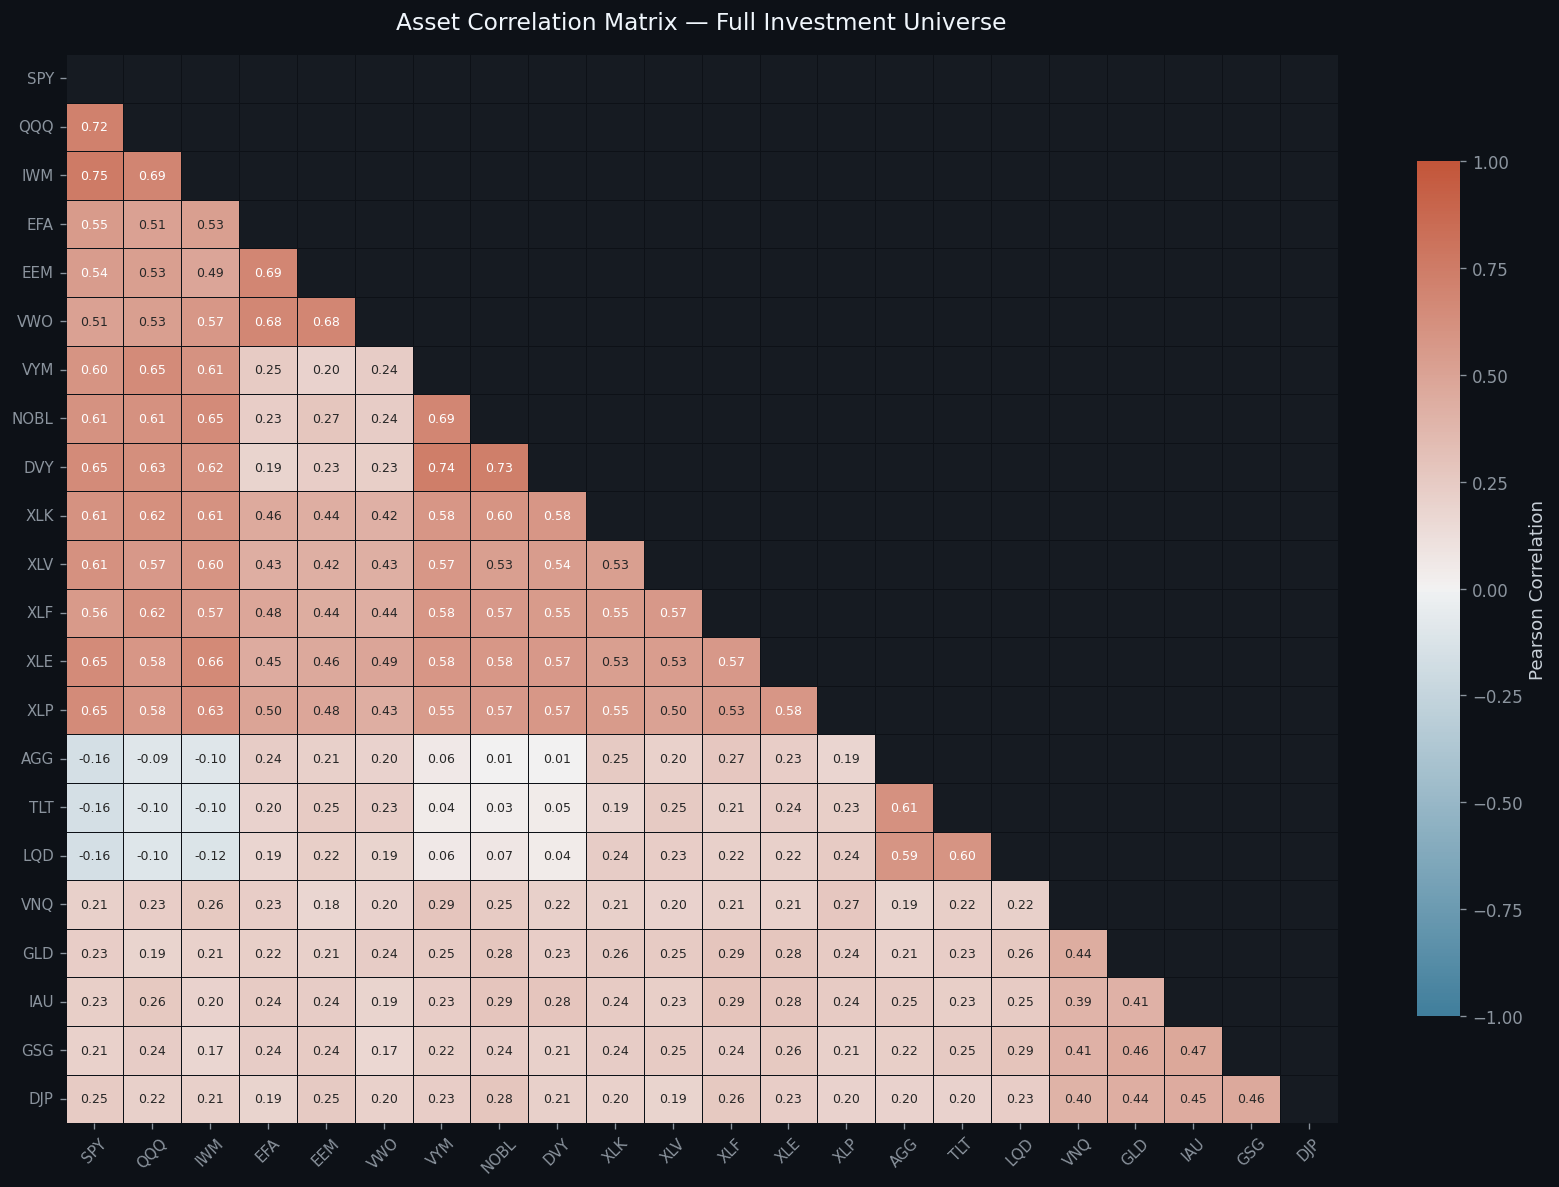


Key Observation: Fixed Income assets (AGG, TLT, LQD) show near-zero or negative
correlation with equities — confirming diversification value.


In [5]:
# ============================================================
# SECTION 6A: CORRELATION HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(14, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='#0d1117',
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Asset Correlation Matrix — Full Investment Universe', pad=15, fontsize=14, color='#f0f6fc')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

print("\nKey Observation: Fixed Income assets (AGG, TLT, LQD) show near-zero or negative")
print("correlation with equities — confirming diversification value.")

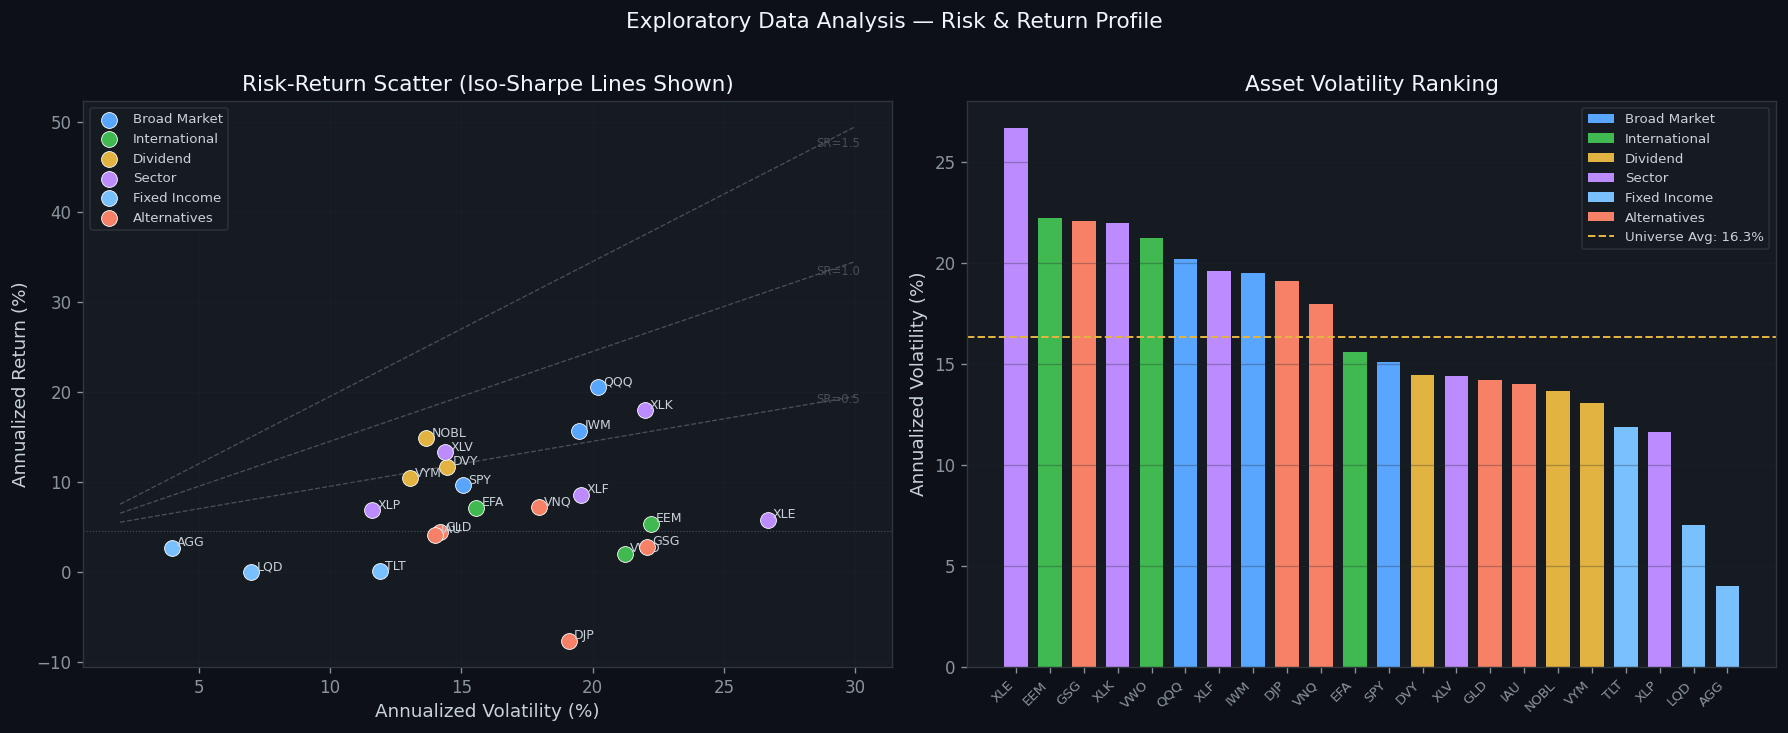

In [6]:
# ============================================================
# SECTION 6B: RETURN vs VOLATILITY SCATTER + ASSET CLASS BAR
# ============================================================

# Color map by asset class
class_colors = {
    'Broad Market': ACCENT,
    'International': GREEN,
    'Dividend': YELLOW,
    'Sector': PURPLE,
    'Fixed Income': '#79c0ff',
    'Alternatives': ORANGE,
}
ticker_class = {t: UNIVERSE[t]['class'] for t in CLEAN_TICKERS}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Scatter: Return vs Volatility ─────────────────────────────
ax = axes[0]
for cls, col in class_colors.items():
    mask = [ticker_class[t] == cls for t in CLEAN_TICKERS]
    tks  = [t for t, m in zip(CLEAN_TICKERS, mask) if m]
    ax.scatter(
        ann_vol[tks] * 100, ann_returns[tks] * 100,
        c=col, label=cls, s=90, zorder=3, edgecolors='white', linewidths=0.5
    )
    for t in tks:
        ax.annotate(t, (ann_vol[t]*100 + 0.2, ann_returns[t]*100 + 0.2),
                    fontsize=7.5, color='#c9d1d9')

# Sharpe ratio iso-lines
vol_range = np.linspace(2, 30, 200)
for sr in [0.5, 1.0, 1.5]:
    ax.plot(vol_range, RISK_FREE*100 + sr * vol_range,
            '--', lw=0.8, color='#484f58', zorder=1)
    ax.text(28.5, RISK_FREE*100 + sr*28.5, f'SR={sr}', fontsize=7, color='#484f58')

ax.axhline(RISK_FREE*100, color='#484f58', lw=0.7, ls=':')
ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')
ax.set_title('Risk-Return Scatter (Iso-Sharpe Lines Shown)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# ── Bar: Asset Volatility ──────────────────────────────────────
ax2 = axes[1]
sorted_vol = ann_vol.sort_values(ascending=False)
bar_colors = [class_colors[ticker_class[t]] for t in sorted_vol.index]
bars = ax2.bar(range(len(sorted_vol)), sorted_vol.values * 100,
               color=bar_colors, edgecolor='none', width=0.7)
ax2.set_xticks(range(len(sorted_vol)))
ax2.set_xticklabels(sorted_vol.index, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Annualized Volatility (%)')
ax2.set_title('Asset Volatility Ranking')
ax2.axhline(ann_vol.mean()*100, color=YELLOW, ls='--', lw=1.2, label=f'Universe Avg: {ann_vol.mean()*100:.1f}%')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# Legend proxy patches for bar chart
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=col, label=cls) for cls, col in class_colors.items()]
ax2.legend(handles=legend_patches + [plt.Line2D([0],[0], color=YELLOW, ls='--', lw=1.2,
           label=f'Universe Avg: {ann_vol.mean()*100:.1f}%')], fontsize=8)

plt.suptitle('Exploratory Data Analysis — Risk & Return Profile', y=1.01, fontsize=13, color='#f0f6fc')
plt.tight_layout()
plt.show()

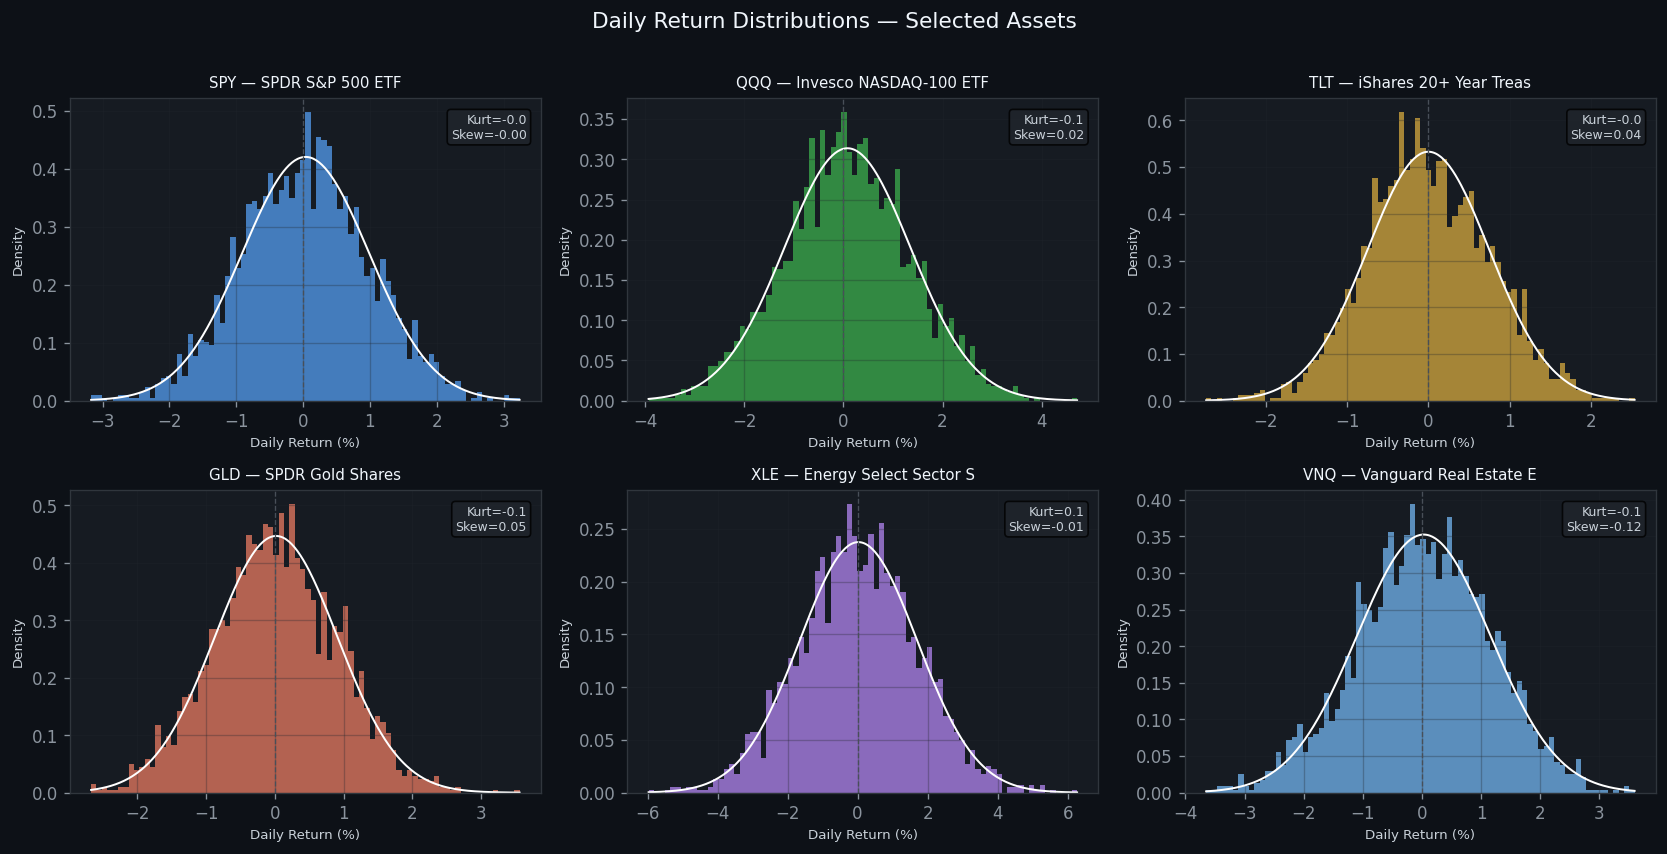

Note: Excess kurtosis > 3 indicates fat tails — more extreme events than normal distribution predicts.


In [7]:
# ============================================================
# SECTION 6C: RETURN DISTRIBUTION PANEL
# ============================================================

highlight = ['SPY', 'QQQ', 'TLT', 'GLD', 'XLE', 'VNQ']
colors_h  = [ACCENT, GREEN, YELLOW, ORANGE, PURPLE, '#79c0ff']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, (ticker, color) in enumerate(zip(highlight, colors_h)):
    ax = axes[i]
    ret = daily_rets[ticker].dropna() * 100
    ax.hist(ret, bins=80, color=color, alpha=0.7, edgecolor='none', density=True)

    # Normal distribution overlay
    x = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()),
            color='white', lw=1.2, label='Normal Fit')

    kurt  = stats.kurtosis(ret)
    skew_ = stats.skew(ret)
    ax.axvline(0, color='#484f58', lw=0.8, ls='--')
    ax.set_title(f'{ticker} — {UNIVERSE[ticker]["name"][:22]}', fontsize=9)
    ax.set_xlabel('Daily Return (%)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.text(0.97, 0.95, f'Kurt={kurt:.1f}\nSkew={skew_:.2f}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            color='#c9d1d9', bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262d', alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.suptitle('Daily Return Distributions — Selected Assets', fontsize=13, y=1.01, color='#f0f6fc')
plt.tight_layout()
plt.show()
print("Note: Excess kurtosis > 3 indicates fat tails — more extreme events than normal distribution predicts.")

In [8]:
# ============================================================
# SECTION 7: BASELINE ASSET SUMMARY TABLE
# ============================================================

def compute_asset_table(tickers, ann_returns, ann_vol, sharpe, universe):
    """Build ranked summary table for all assets."""
    rows = []
    for t in tickers:
        rows.append({
            'Ticker':      t,
            'Name':        universe[t]['name'],
            'Asset Class': universe[t]['class'],
            'Ann. Return': ann_returns[t],
            'Ann. Volatility': ann_vol[t],
            'Sharpe Ratio': sharpe[t],
        })
    df = pd.DataFrame(rows).sort_values('Sharpe Ratio', ascending=False).reset_index(drop=True)
    df.index += 1
    return df


asset_table = compute_asset_table(CLEAN_TICKERS, ann_returns, ann_vol, sharpe, UNIVERSE)

# Format for display
display_table = asset_table.copy()
display_table['Ann. Return']     = display_table['Ann. Return'].map('{:.2%}'.format)
display_table['Ann. Volatility'] = display_table['Ann. Volatility'].map('{:.2%}'.format)
display_table['Sharpe Ratio']    = display_table['Sharpe Ratio'].map('{:.3f}'.format)
print("=" * 95)
print("BASELINE ASSET RANKINGS — Sorted by Sharpe Ratio (Descending)")
print("=" * 95)
print(display_table.to_string())
print("=" * 95)

# Top 5 and Bottom 5
print(f"\n▲ Top 5 by Sharpe: {', '.join(asset_table.head(5)['Ticker'].tolist())}")
print(f"▼ Bot 5 by Sharpe: {', '.join(asset_table.tail(5)['Ticker'].tolist())}")

BASELINE ASSET RANKINGS — Sorted by Sharpe Ratio (Descending)
   Ticker                            Name    Asset Class Ann. Return Ann. Volatility Sharpe Ratio
1     QQQ          Invesco NASDAQ-100 ETF   Broad Market      20.51%          20.19%        0.793
2    NOBL   ProShares S&P 500 Aristocrats       Dividend      14.82%          13.66%        0.756
3     XLK   Technology Select Sector SPDR         Sector      17.94%          21.98%        0.612
4     XLV  Health Care Select Sector SPDR         Sector      13.29%          14.38%        0.611
5     IWM        iShares Russell 2000 ETF   Broad Market      15.69%          19.48%        0.574
6     DVY     iShares Dividend Select ETF       Dividend      11.69%          14.46%        0.498
7     VYM    Vanguard High Dividend Yield       Dividend      10.40%          13.03%        0.453
8     SPY                SPDR S&P 500 ETF   Broad Market       9.60%          15.06%        0.339
9     XLF    Financial Select Sector SPDR         Sector

In [9]:
# ============================================================
# SECTION 8: PORTFOLIO OPTIMIZATION ENGINE
# ============================================================

def portfolio_performance(weights: np.ndarray, ann_returns: pd.Series,
                           cov_matrix: pd.DataFrame) -> tuple:
    """Compute portfolio return, volatility, and Sharpe ratio."""
    port_ret = float(weights @ ann_returns.values)
    port_vol = float(np.sqrt(weights @ cov_matrix.values @ weights))
    sharpe   = (port_ret - RISK_FREE) / port_vol
    return port_ret, port_vol, sharpe


def negative_sharpe(weights, ann_returns, cov_matrix):
    """Objective: minimize negative Sharpe (= maximize Sharpe)."""
    _, _, sr = portfolio_performance(weights, ann_returns, cov_matrix)
    return -sr


def optimize_portfolio(tickers: list, ann_returns: pd.Series,
                        cov_matrix: pd.DataFrame,
                        universe: dict,
                        max_weight: float = 0.25,
                        max_fi_alloc: float = 0.35,
                        max_alt_alloc: float = 0.25) -> dict:
    """Run mean-variance optimization with institutional constraints."""
    n = len(tickers)
    bounds = [(0.0, max_weight)] * n

    # ── Constraints ───────────────────────────────────────────
    constraints = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1.0},  # weights sum to 1
    ]

    # Asset class caps
    fi_idx  = [i for i, t in enumerate(tickers) if universe.get(t, {}).get('class') == 'Fixed Income']
    alt_idx = [i for i, t in enumerate(tickers) if universe.get(t, {}).get('class') == 'Alternatives']

    if fi_idx:
        constraints.append({'type': 'ineq', 'fun': lambda w, idx=fi_idx: max_fi_alloc - np.sum(w[idx])})
    if alt_idx:
        constraints.append({'type': 'ineq', 'fun': lambda w, idx=alt_idx: max_alt_alloc - np.sum(w[idx])})

    mu_sub  = ann_returns[tickers]
    cov_sub = cov_matrix.loc[tickers, tickers]

    best_result = None
    best_sr     = -np.inf

    # Multiple random starts for robustness
    for seed in range(50):
        np.random.seed(seed)
        w0 = np.random.dirichlet(np.ones(n))
        res = minimize(
            negative_sharpe, w0,
            args=(mu_sub, cov_sub),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-12, 'maxiter': 1000}
        )
        if res.success and (-res.fun) > best_sr:
            best_sr     = -res.fun
            best_result = res

    weights = best_result.x
    weights[weights < 0.001] = 0  # clean negligible weights
    weights /= weights.sum()

    port_ret, port_vol, port_sr = portfolio_performance(weights, mu_sub, cov_sub)

    return {
        'weights':  pd.Series(weights, index=tickers),
        'return':   port_ret,
        'vol':      port_vol,
        'sharpe':   port_sr,
    }


# ── Run optimization ──────────────────────────────────────────
opt_result = optimize_portfolio(
    CLEAN_TICKERS, ann_returns, cov_matrix, UNIVERSE
)

opt_weights = opt_result['weights']
nonzero_wts = opt_weights[opt_weights > 0.001].sort_values(ascending=False)

print("=" * 60)
print("OPTIMIZED PORTFOLIO — Maximum Sharpe Ratio")
print("=" * 60)
print(f"  Expected Annual Return  : {opt_result['return']:.2%}")
print(f"  Expected Annual Volatil : {opt_result['vol']:.2%}")
print(f"  Sharpe Ratio            : {opt_result['sharpe']:.3f}")
print(f"  # Active Positions      : {(opt_weights > 0.001).sum()}")
print("\n  Optimal Weights:")
for t, w in nonzero_wts.items():
    print(f"    {t:6s} {UNIVERSE[t]['name'][:30]:30s} {w:.2%}")

OPTIMIZED PORTFOLIO — Maximum Sharpe Ratio
  Expected Annual Return  : 16.30%
  Expected Annual Volatil : 14.13%
  Sharpe Ratio            : 0.835
  # Active Positions      : 6

  Optimal Weights:
    QQQ    Invesco NASDAQ-100 ETF         25.00%
    NOBL   ProShares S&P 500 Aristocrats  25.00%
    XLV    Health Care Select Sector SPDR 25.00%
    XLK    Technology Select Sector SPDR  18.49%
    IWM    iShares Russell 2000 ETF       4.16%
    VNQ    Vanguard Real Estate ETF       2.35%


In [10]:
# ============================================================
# SECTION 9: ADD/REMOVE STRATEGY TESTING
# ============================================================

def evaluate_subset(tickers_subset, ann_returns, cov_matrix, universe):
    """Quick evaluation of a portfolio subset."""
    if len(tickers_subset) < 2:
        return None
    try:
        res = optimize_portfolio(tickers_subset, ann_returns, cov_matrix, universe)
        return res
    except Exception:
        return None


print("Starting Add/Remove Analysis...")
print("-" * 65)

# Baseline: full universe
current_tickers = CLEAN_TICKERS.copy()
baseline = evaluate_subset(current_tickers, ann_returns, cov_matrix, UNIVERSE)
print(f"Full Universe ({len(current_tickers)} assets) → Sharpe: {baseline['sharpe']:.4f}")

removal_log = []

# ── Removal pass ──────────────────────────────────────────────
improved = True
current_sharpe = baseline['sharpe']

while improved and len(current_tickers) > 6:
    improved       = False
    best_candidate = None
    best_sharpe    = current_sharpe

    for t in current_tickers:
        test_tickers = [x for x in current_tickers if x != t]
        res          = evaluate_subset(test_tickers, ann_returns, cov_matrix, UNIVERSE)
        if res and res['sharpe'] > best_sharpe:
            best_sharpe    = res['sharpe']
            best_candidate = t
            best_res       = res

    if best_candidate:
        current_tickers.remove(best_candidate)
        current_sharpe = best_sharpe
        improved       = True
        removal_log.append({
            'Action': f'Remove {best_candidate}',
            '# Assets': len(current_tickers),
            'Portfolio Sharpe': best_sharpe,
            'Delta Sharpe': best_sharpe - baseline['sharpe']
        })
        print(f"  Removed {best_candidate:6s} → Sharpe: {best_sharpe:.4f} "
              f"(Δ={best_sharpe - baseline['sharpe']:+.4f})")

# Final optimized portfolio after removal
refined_result  = evaluate_subset(current_tickers, ann_returns, cov_matrix, UNIVERSE)
FINAL_TICKERS   = current_tickers.copy()

print(f"\nPost-Removal Portfolio ({len(FINAL_TICKERS)} assets) → Sharpe: {refined_result['sharpe']:.4f}")
print(f"Improvement vs Full Universe: {refined_result['sharpe'] - baseline['sharpe']:+.4f}")

if removal_log:
    removal_df = pd.DataFrame(removal_log)
    print("\n", removal_df.to_string(index=False))

Starting Add/Remove Analysis...
-----------------------------------------------------------------
Full Universe (22 assets) → Sharpe: 0.8351
  Removed GSG    → Sharpe: 0.8351 (Δ=+0.0000)

Post-Removal Portfolio (21 assets) → Sharpe: 0.8351
Improvement vs Full Universe: +0.0000

     Action  # Assets  Portfolio Sharpe  Delta Sharpe
Remove GSG        21          0.835061  6.661338e-16


PORTFOLIO vs BENCHMARK — Performance Comparison
Metric                   Opt. Portfolio      S&P 500 (SPY)
------------------------------------------------------------
  Ann. Return                    16.30%              9.60%
  Volatility                     14.13%             15.06%
  Sharpe Ratio                    0.835              0.339
  Max Drawdown                  -24.57%            -43.78%
  Calmar Ratio                    0.663              0.219
  Total Return                  386.87%            140.24%

  Annual Alpha vs Benchmark: +6.69%


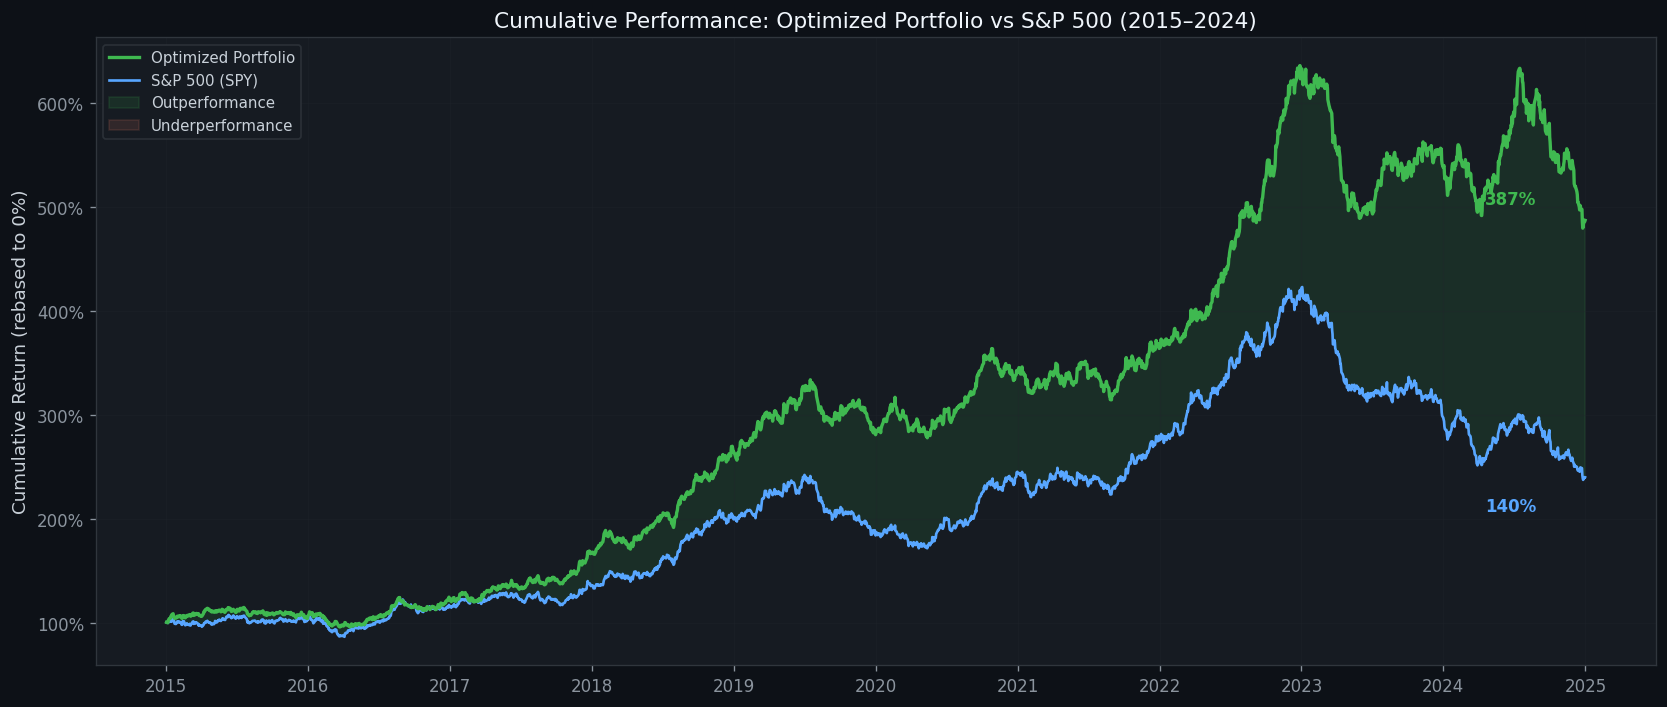

In [11]:
# ============================================================
# SECTION 10: BENCHMARK COMPARISON
# ============================================================

def compute_portfolio_returns(weights: pd.Series, daily_rets: pd.DataFrame) -> pd.Series:
    """Compute daily portfolio return series from individual asset returns."""
    aligned = daily_rets[weights.index].dropna()
    port_ret = (aligned * weights.values).sum(axis=1)
    return port_ret


def performance_summary(ret_series: pd.Series, label: str, rf: float = RISK_FREE) -> dict:
    """Compute comprehensive performance metrics for a return series."""
    ann_ret  = ret_series.mean() * TRADING_DAYS
    ann_vol_ = ret_series.std()  * np.sqrt(TRADING_DAYS)
    sharpe_  = (ann_ret - rf) / ann_vol_
    cum_ret  = (1 + ret_series).cumprod()
    drawdown = (cum_ret / cum_ret.cummax() - 1)
    max_dd   = drawdown.min()
    total    = cum_ret.iloc[-1] - 1
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return {
        'Label':           label,
        'Ann. Return':     ann_ret,
        'Volatility':      ann_vol_,
        'Sharpe Ratio':    sharpe_,
        'Max Drawdown':    max_dd,
        'Calmar Ratio':    calmar,
        'Total Return':    total,
        '_cum':            cum_ret,
        '_dd':             drawdown,
    }


# Final optimized portfolio weights
final_opt = evaluate_subset(FINAL_TICKERS, ann_returns, cov_matrix, UNIVERSE)
final_weights = final_opt['weights']

port_daily = compute_portfolio_returns(final_weights, daily_rets)
bench_daily = daily_rets['SPY']

port_stats  = performance_summary(port_daily,  'Optimized Portfolio')
bench_stats = performance_summary(bench_daily, 'S&P 500 (SPY)')

# ── Print comparison table ────────────────────────────────────
metrics = ['Ann. Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown', 'Calmar Ratio', 'Total Return']
print("=" * 60)
print("PORTFOLIO vs BENCHMARK — Performance Comparison")
print("=" * 60)
print(f"{'Metric':<20} {'Opt. Portfolio':>18} {'S&P 500 (SPY)':>18}")
print("-" * 60)
for m in metrics:
    fmt = '.2%' if m != 'Sharpe Ratio' and m != 'Calmar Ratio' else '.3f'
    pv  = port_stats[m]
    bv  = bench_stats[m]
    print(f"  {m:<18} {format(pv, fmt):>18} {format(bv, fmt):>18}")
print("=" * 60)

alpha = port_stats['Ann. Return'] - bench_stats['Ann. Return']
print(f"\n  Annual Alpha vs Benchmark: {alpha:+.2%}")

# ── Cumulative Return Plot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

cum_port  = (1 + port_daily).cumprod()
cum_bench = (1 + bench_daily).cumprod()

ax.plot(cum_port.index,  cum_port.values,  color=GREEN,  lw=2.0, label='Optimized Portfolio', zorder=3)
ax.plot(cum_bench.index, cum_bench.values, color=ACCENT,  lw=1.6, label='S&P 500 (SPY)',       zorder=2)
ax.fill_between(cum_port.index, cum_port.values, cum_bench.values,
                where=cum_port.values >= cum_bench.values,
                alpha=0.12, color=GREEN, label='Outperformance')
ax.fill_between(cum_port.index, cum_port.values, cum_bench.values,
                where=cum_port.values < cum_bench.values,
                alpha=0.12, color=ORANGE, label='Underperformance')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_ylabel('Cumulative Return (rebased to 0%)')
ax.set_title('Cumulative Performance: Optimized Portfolio vs S&P 500 (2015–2024)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate final values
ax.annotate(f"{cum_port.iloc[-1]-1:.0%}",
            xy=(cum_port.index[-1], cum_port.iloc[-1]),
            xytext=(-60, 10), textcoords='offset points',
            color=GREEN, fontsize=10, fontweight='bold')
ax.annotate(f"{cum_bench.iloc[-1]-1:.0%}",
            xy=(cum_bench.index[-1], cum_bench.iloc[-1]),
            xytext=(-60, -20), textcoords='offset points',
            color=ACCENT, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Simulating efficient frontier (10,000 portfolios)...


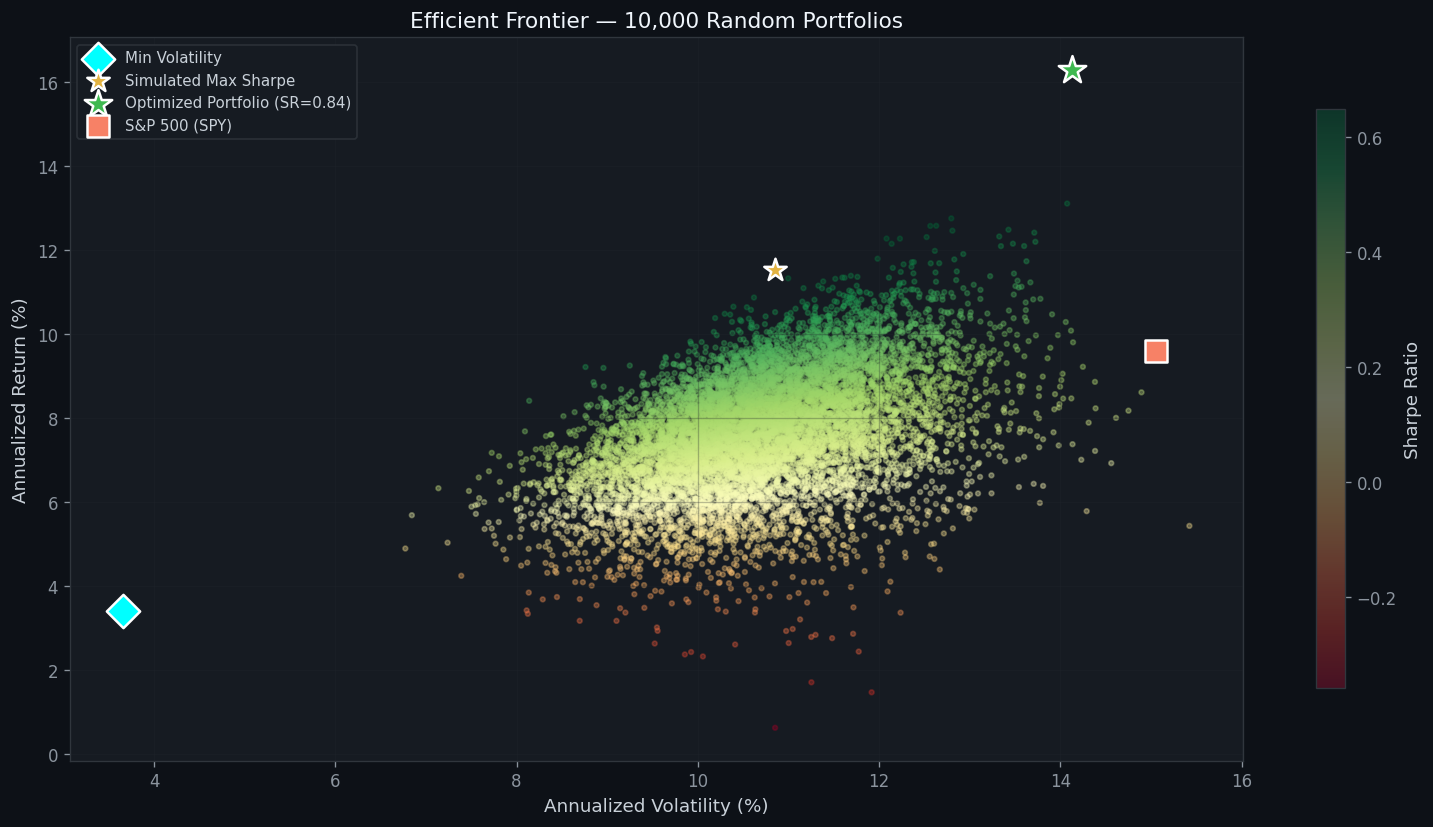

Min Volatility Portfolio: Return=3.39%, Vol=3.66%, Sharpe=-0.304
Max Sharpe Portfolio    : Return=11.53%, Vol=10.85%, Sharpe=0.648


In [12]:
# ============================================================
# SECTION 11: EFFICIENT FRONTIER
# ============================================================

def simulate_random_portfolios(tickers, ann_returns, cov_matrix, n_sim=10000):
    """Monte Carlo simulation of random portfolio weights."""
    np.random.seed(42)
    n = len(tickers)
    mu_sub  = ann_returns[tickers].values
    cov_sub = cov_matrix.loc[tickers, tickers].values

    results = np.zeros((n_sim, 3))
    weight_store = np.zeros((n_sim, n))

    for i in range(n_sim):
        w = np.random.dirichlet(np.ones(n))
        r = float(w @ mu_sub)
        v = float(np.sqrt(w @ cov_sub @ w))
        s = (r - RISK_FREE) / v
        results[i]       = [r, v, s]
        weight_store[i]  = w

    return results, weight_store


def min_vol_portfolio(tickers, ann_returns, cov_matrix):
    """Find minimum variance portfolio."""
    n = len(tickers)
    cov_sub = cov_matrix.loc[tickers, tickers].values
    mu_sub  = ann_returns[tickers].values
    w0      = np.ones(n) / n
    bounds  = [(0, 1)] * n
    cons    = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

    res = minimize(lambda w: float(np.sqrt(w @ cov_sub @ w)), w0,
                   method='SLSQP', bounds=bounds, constraints=cons,
                   options={'ftol': 1e-12, 'maxiter': 1000})
    w = res.x
    r = float(w @ mu_sub)
    v = float(np.sqrt(w @ cov_sub @ w))
    s = (r - RISK_FREE) / v
    return w, r, v, s


print("Simulating efficient frontier (10,000 portfolios)...")
sim_results, sim_weights = simulate_random_portfolios(
    FINAL_TICKERS, ann_returns, cov_matrix, n_sim=10000
)

mv_w, mv_r, mv_v, mv_s = min_vol_portfolio(FINAL_TICKERS, ann_returns, cov_matrix)
ms_idx = np.argmax(sim_results[:, 2])

fig, ax = plt.subplots(figsize=(13, 7))

sc = ax.scatter(
    sim_results[:, 1] * 100,
    sim_results[:, 0] * 100,
    c=sim_results[:, 2], cmap='RdYlGn',
    alpha=0.35, s=8, zorder=1
)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio', shrink=0.8)

# Key portfolios
kw = dict(zorder=5, edgecolors='white', linewidths=1.5)
ax.scatter(mv_v*100, mv_r*100, c='cyan',   s=200, marker='D', label='Min Volatility', **kw)
ax.scatter(sim_results[ms_idx,1]*100, sim_results[ms_idx,0]*100,
           c=YELLOW, s=200, marker='*', label='Simulated Max Sharpe', **kw)
ax.scatter(final_opt['vol']*100, final_opt['return']*100,
           c=GREEN, s=300, marker='*', label=f'Optimized Portfolio (SR={final_opt["sharpe"]:.2f})', **kw)
ax.scatter(bench_stats['Volatility']*100, bench_stats['Ann. Return']*100,
           c=ORANGE, s=180, marker='s', label='S&P 500 (SPY)', **kw)

ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')
ax.set_title('Efficient Frontier — 10,000 Random Portfolios', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Min Volatility Portfolio: Return={mv_r:.2%}, Vol={mv_v:.2%}, Sharpe={mv_s:.3f}")
print(f"Max Sharpe Portfolio    : Return={sim_results[ms_idx,0]:.2%}, Vol={sim_results[ms_idx,1]:.2%}, Sharpe={sim_results[ms_idx,2]:.3f}")


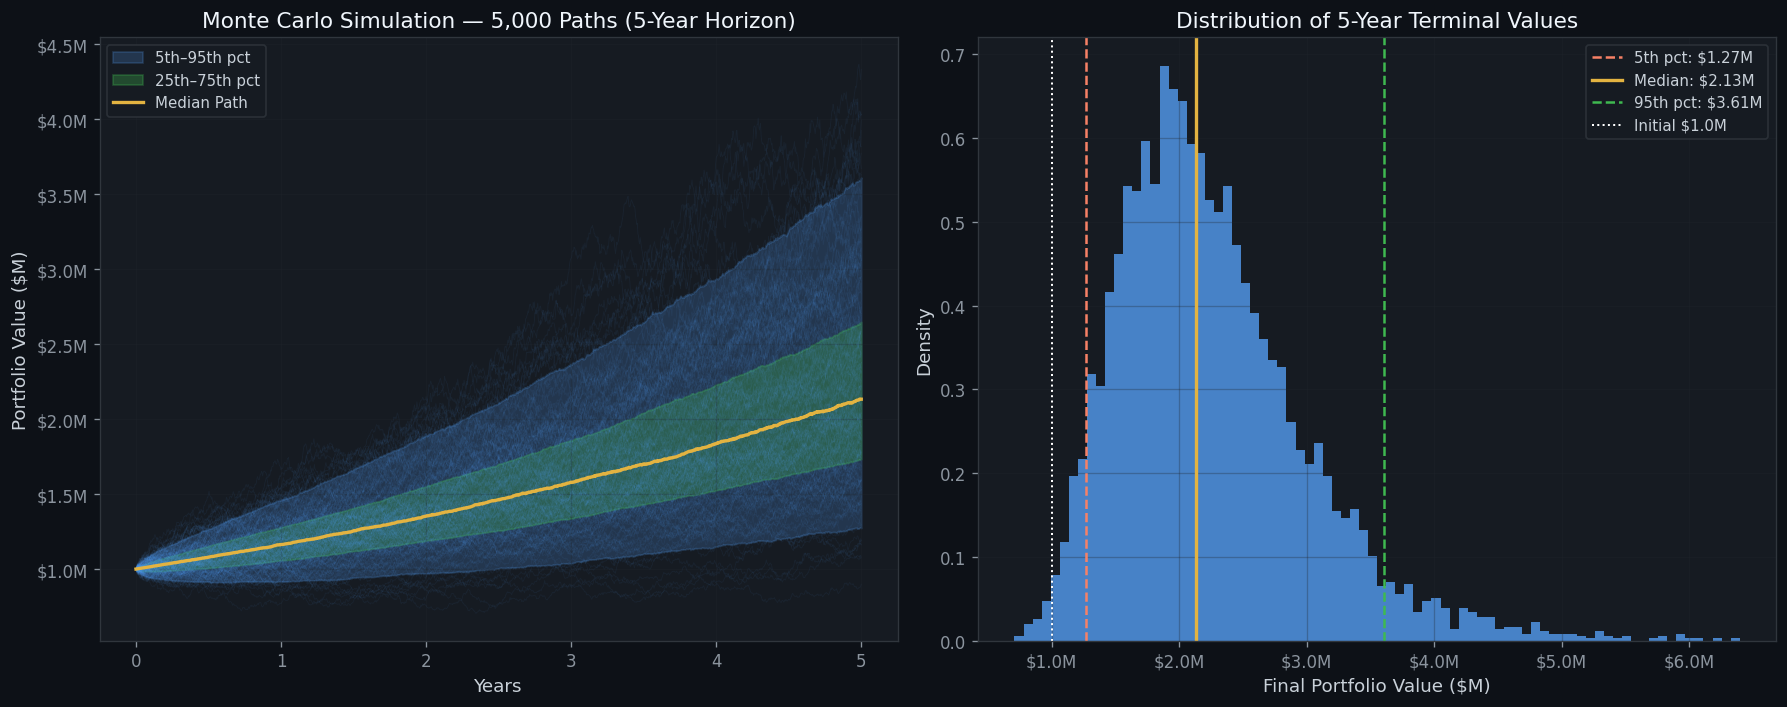


Monte Carlo Summary (5-Year, $1M Initial Investment):
  5th  Percentile : $1.27M
  25th Percentile : $1.73M
  Median          : $2.13M
  75th Percentile : $2.65M
  95th Percentile : $3.61M
  Prob of Loss    : 0.7%


In [13]:
# ============================================================
# SECTION 12: MONTE CARLO SIMULATION
# ============================================================

def monte_carlo_simulation(port_ret: float, port_vol: float,
                             n_sims: int = 5000,
                             n_days: int = 252 * 5,
                             initial_value: float = 1_000_000) -> np.ndarray:
    """Simulate portfolio value paths using GBM."""
    np.random.seed(42)
    dt    = 1 / TRADING_DAYS
    drift = (port_ret - 0.5 * port_vol**2) * dt
    shock = port_vol * np.sqrt(dt)

    rand_returns = np.exp(drift + shock * np.random.randn(n_days, n_sims))
    paths        = initial_value * np.cumprod(rand_returns, axis=0)
    # Prepend starting value
    paths = np.vstack([np.full((1, n_sims), initial_value), paths])
    return paths


INITIAL_VALUE = 1_000_000
N_SIMS        = 5000
HORIZON_DAYS  = 252 * 5

mc_paths = monte_carlo_simulation(
    final_opt['return'], final_opt['vol'],
    n_sims=N_SIMS, n_days=HORIZON_DAYS, initial_value=INITIAL_VALUE
)

final_values = mc_paths[-1, :]
p5,  p25, p50, p75, p95 = np.percentile(final_values, [5, 25, 50, 75, 95])

# ── Plot: MC paths + percentile bands ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Paths chart
ax = axes[0]
years = np.linspace(0, 5, HORIZON_DAYS + 1)

# Plot 200 random paths (faint)
for i in np.random.choice(N_SIMS, 200, replace=False):
    ax.plot(years, mc_paths[:, i] / 1e6, alpha=0.06, lw=0.5, color=ACCENT)

# Percentile bands
pct_5  = np.percentile(mc_paths, 5,  axis=1)
pct_25 = np.percentile(mc_paths, 25, axis=1)
pct_50 = np.percentile(mc_paths, 50, axis=1)
pct_75 = np.percentile(mc_paths, 75, axis=1)
pct_95 = np.percentile(mc_paths, 95, axis=1)

ax.fill_between(years, pct_5/1e6,  pct_95/1e6, alpha=0.20, color=ACCENT, label='5th–95th pct')
ax.fill_between(years, pct_25/1e6, pct_75/1e6, alpha=0.30, color=GREEN,  label='25th–75th pct')
ax.plot(years, pct_50/1e6, color=YELLOW, lw=2.0, label='Median Path')

ax.set_xlabel('Years')
ax.set_ylabel('Portfolio Value ($M)')
ax.set_title(f'Monte Carlo Simulation — {N_SIMS:,} Paths (5-Year Horizon)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# Final value distribution
ax2 = axes[1]
ax2.hist(final_values / 1e6, bins=80, color=ACCENT, alpha=0.75, edgecolor='none', density=True)
ax2.axvline(p5/1e6,  color=ORANGE, lw=1.5, ls='--', label=f'5th pct: ${p5/1e6:.2f}M')
ax2.axvline(p50/1e6, color=YELLOW, lw=2.0, ls='-',  label=f'Median: ${p50/1e6:.2f}M')
ax2.axvline(p95/1e6, color=GREEN,  lw=1.5, ls='--', label=f'95th pct: ${p95/1e6:.2f}M')
ax2.axvline(INITIAL_VALUE/1e6, color='white', lw=1.2, ls=':', label='Initial $1.0M')
ax2.set_xlabel('Final Portfolio Value ($M)')
ax2.set_ylabel('Density')
ax2.set_title('Distribution of 5-Year Terminal Values')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.1f}M'))

plt.tight_layout()
plt.show()

prob_loss = np.mean(final_values < INITIAL_VALUE)
print(f"\nMonte Carlo Summary (5-Year, $1M Initial Investment):")
print(f"  5th  Percentile : ${p5/1e6:.2f}M")
print(f"  25th Percentile : ${p25/1e6:.2f}M")
print(f"  Median          : ${p50/1e6:.2f}M")
print(f"  75th Percentile : ${p75/1e6:.2f}M")
print(f"  95th Percentile : ${p95/1e6:.2f}M")
print(f"  Prob of Loss    : {prob_loss:.1%}")


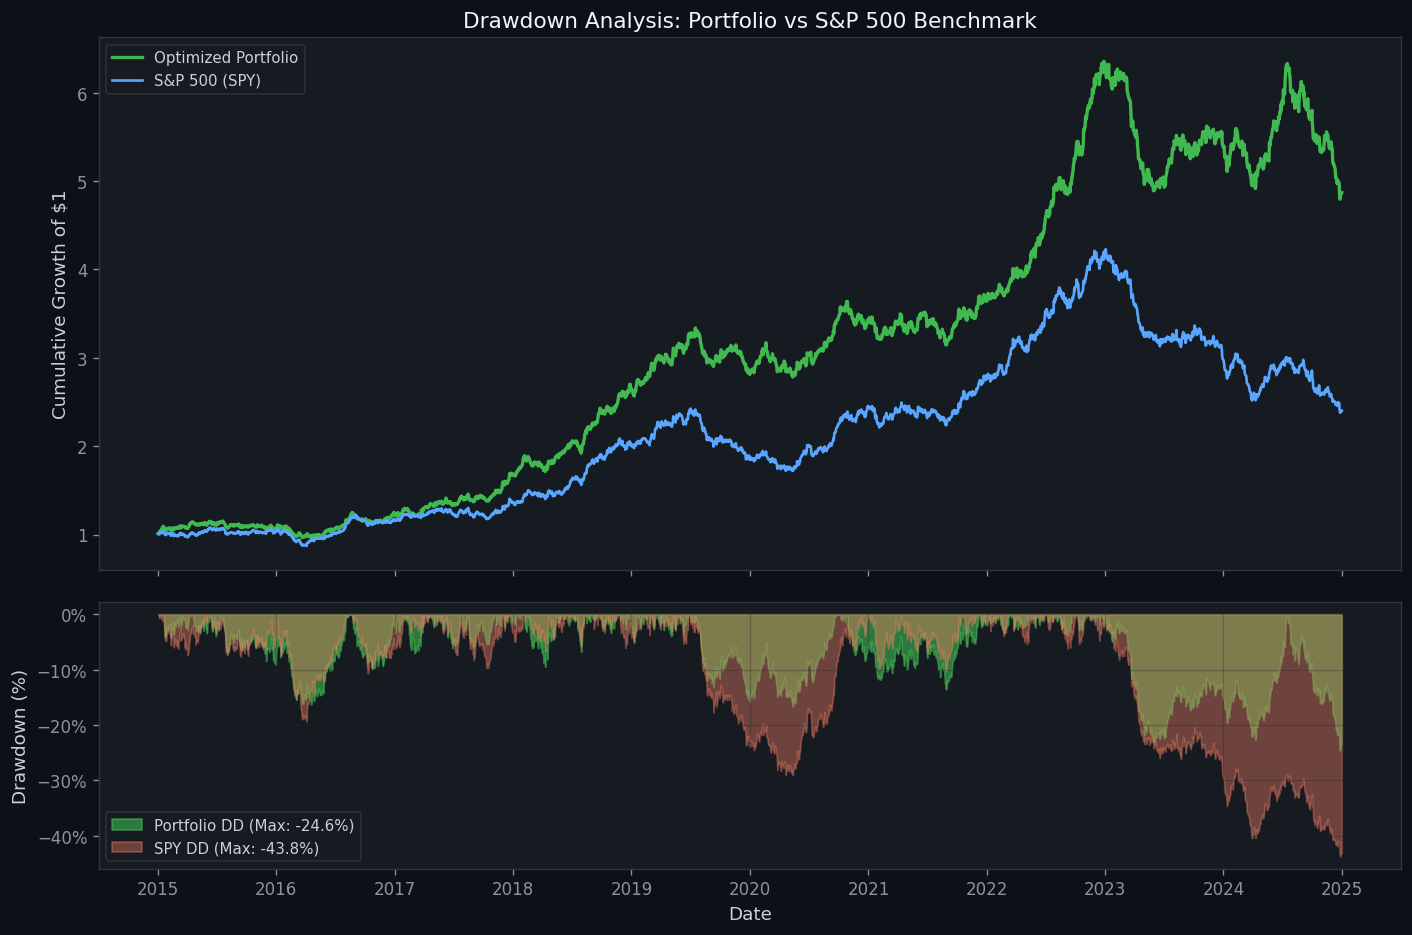

Portfolio Max Drawdown : -24.57%
Benchmark Max Drawdown : -43.78%
Drawdown Reduction     : -19.22%

Top 3 Longest Drawdown Periods (Portfolio):
  2023-03-10 → 2024-07-15 (493 days)
  2019-08-05 → 2020-09-18 (410 days)
  2020-11-12 → 2021-12-06 (389 days)


In [14]:
# ============================================================
# SECTION 13: DRAWDOWN ANALYSIS
# ============================================================

def compute_drawdown(ret_series: pd.Series) -> pd.Series:
    """Compute drawdown series from daily returns."""
    cum = (1 + ret_series).cumprod()
    dd  = cum / cum.cummax() - 1
    return cum, dd


port_cum,  port_dd  = compute_drawdown(port_daily)
bench_cum, bench_dd = compute_drawdown(bench_daily)

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.08)

# Cumulative returns
ax1 = fig.add_subplot(gs[0])
ax1.plot(port_cum.index,  port_cum.values,  color=GREEN,  lw=2.0, label='Optimized Portfolio')
ax1.plot(bench_cum.index, bench_cum.values, color=ACCENT,  lw=1.6, label='S&P 500 (SPY)')
ax1.set_ylabel('Cumulative Growth of $1')
ax1.set_title('Drawdown Analysis: Portfolio vs S&P 500 Benchmark', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels([])

# Drawdowns
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(port_dd.index,  port_dd.values * 100,  0, alpha=0.6, color=GREEN,  label=f'Portfolio DD (Max: {port_dd.min()*100:.1f}%)')
ax2.fill_between(bench_dd.index, bench_dd.values * 100, 0, alpha=0.4, color=ORANGE, label=f'SPY DD (Max: {bench_dd.min()*100:.1f}%)')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.show()

print(f"Portfolio Max Drawdown : {port_dd.min():.2%}")
print(f"Benchmark Max Drawdown : {bench_dd.min():.2%}")
print(f"Drawdown Reduction     : {bench_dd.min() - port_dd.min():.2%}")

# Recovery periods
def find_recovery_periods(dd_series):
    in_dd   = dd_series < -0.05
    periods = []
    start   = None
    for i, (dt, val) in enumerate(dd_series.items()):
        if val < -0.05 and start is None:
            start = dt
        elif val >= -0.005 and start is not None:
            periods.append((start, dt, (dt - start).days))
            start = None
    return sorted(periods, key=lambda x: -x[2])[:3]

print("\nTop 3 Longest Drawdown Periods (Portfolio):")
for s, e, d in find_recovery_periods(port_dd):
    print(f"  {s.date()} → {e.date()} ({d} days)")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     1380.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:57:10   Log-Likelihood:                 9373.2
No. Observations:                2356   AIC:                        -1.873e+04
Df Residuals:                    2350   BIC:                        -1.870e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002   9.36e-05      2.145      0.0

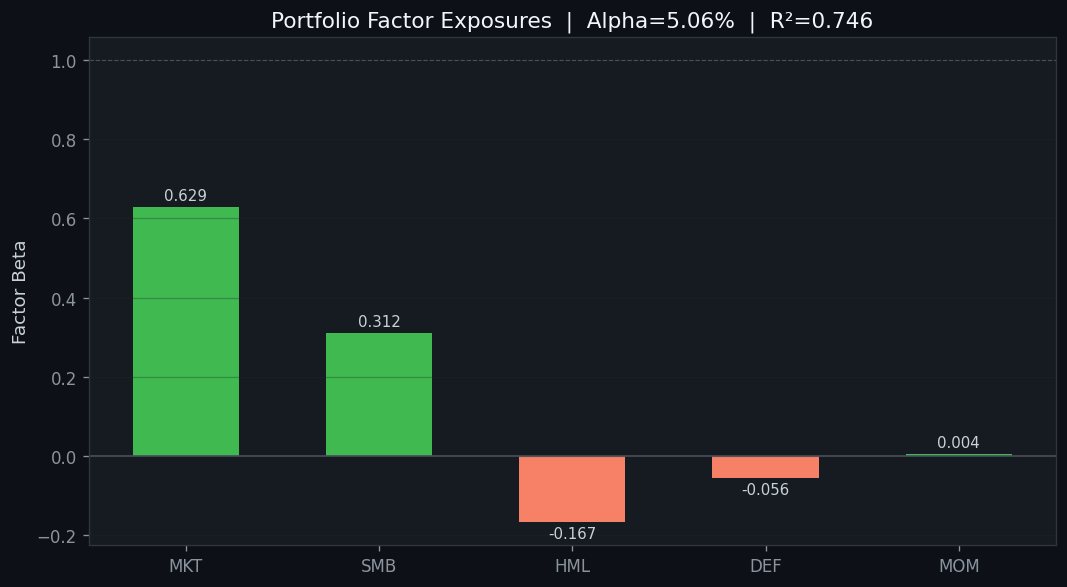

In [15]:
# ============================================================
# SECTION 14: FACTOR EXPOSURE ANALYSIS
# ============================================================

def build_factor_returns(daily_rets: pd.DataFrame, rf_daily: float) -> pd.DataFrame:
    """Construct Fama-French-style factor proxies from available ETFs."""
    factors = pd.DataFrame(index=daily_rets.index)
    # Market excess return
    factors['MKT'] = daily_rets['SPY'] - rf_daily
    # Size: small minus large
    factors['SMB'] = daily_rets['IWM'] - daily_rets['SPY']
    # Value: dividend/value minus growth
    factors['HML'] = daily_rets['VYM'] - daily_rets['QQQ']
    # Defensive: low-vol vs high-vol
    factors['DEF'] = daily_rets['XLP'] - daily_rets['XLE']
    # Momentum: 12-month rolling return signal
    mom_raw = daily_rets['SPY'].rolling(252).sum().shift(1)
    factors['MOM'] = (mom_raw - mom_raw.mean()) / mom_raw.std()
    factors['MOM'] = factors['MOM'] * daily_rets['SPY'].std()
    return factors.dropna()


RF_DAILY = RISK_FREE / TRADING_DAYS
factors  = build_factor_returns(daily_rets, RF_DAILY)

# Align portfolio returns with factors
port_excess = port_daily - RF_DAILY
Y = port_excess.reindex(factors.index).dropna()
X = factors.reindex(Y.index)

# Regression (with or without statsmodels)
if STATSMODELS_AVAILABLE:
    X_const = sm.add_constant(X)
    model   = sm.OLS(Y, X_const).fit()
    alpha_  = model.params['const'] * TRADING_DAYS
    betas   = model.params.drop('const')
    r2      = model.rsquared
    pvals   = model.pvalues.drop('const')
    print(model.summary())
else:
    # Numpy fallback
    X_np = np.column_stack([np.ones(len(X)), X.values])
    coef, res, rank, sv = np.linalg.lstsq(X_np, Y.values, rcond=None)
    alpha_ = coef[0] * TRADING_DAYS
    betas  = pd.Series(coef[1:], index=X.columns)
    y_pred = X_np @ coef
    ss_res = np.sum((Y.values - y_pred)**2)
    ss_tot = np.sum((Y.values - Y.mean())**2)
    r2     = 1 - ss_res / ss_tot
    pvals  = pd.Series(np.nan, index=X.columns)

print(f"\n{'='*55}")
print("FACTOR REGRESSION RESULTS")
print(f"{'='*55}")
print(f"  Alpha (annualized)     : {alpha_:.2%}")
print(f"  R-Squared              : {r2:.3f}")
print(f"  Idiosyncratic Risk (1-R²): {(1-r2):.3f}")
print(f"\n  Factor Betas:")
for factor, beta in betas.items():
    sig = '***' if not pd.isna(pvals[factor]) and pvals[factor] < 0.01 else ''
    print(f"    {factor:6s}: {beta:+.4f} {sig}")

# ── Factor Beta Bar Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors_ = [GREEN if b > 0 else ORANGE for b in betas.values]
bars = ax.bar(betas.index, betas.values, color=colors_, edgecolor='none', width=0.55)
ax.axhline(0, color='#484f58', lw=1.0)
ax.axhline(1, color='#484f58', lw=0.7, ls='--')
for bar, val in zip(bars, betas.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01 * np.sign(val),
            f'{val:.3f}', ha='center', va='bottom' if val > 0 else 'top', fontsize=9)
ax.set_ylabel('Factor Beta')
ax.set_title(f'Portfolio Factor Exposures  |  Alpha={alpha_:.2%}  |  R²={r2:.3f}')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


STRESS TEST RESULTS — Estimated Portfolio Loss
                           Portfolio  S&P 500 Advantage
Market Crash\n(2008-Style)   -40.77%  -45.00%    -4.23%
Rate Shock\n(+300bps)        -14.96%  -18.00%    -3.04%
Stagflation\n(70s-Style)     -17.15%  -25.00%    -7.85%
Tech Selloff\n(2000-Style)   -28.23%  -30.00%    -1.77%
Geopolitical\nShock          -12.61%  -15.00%    -2.39%


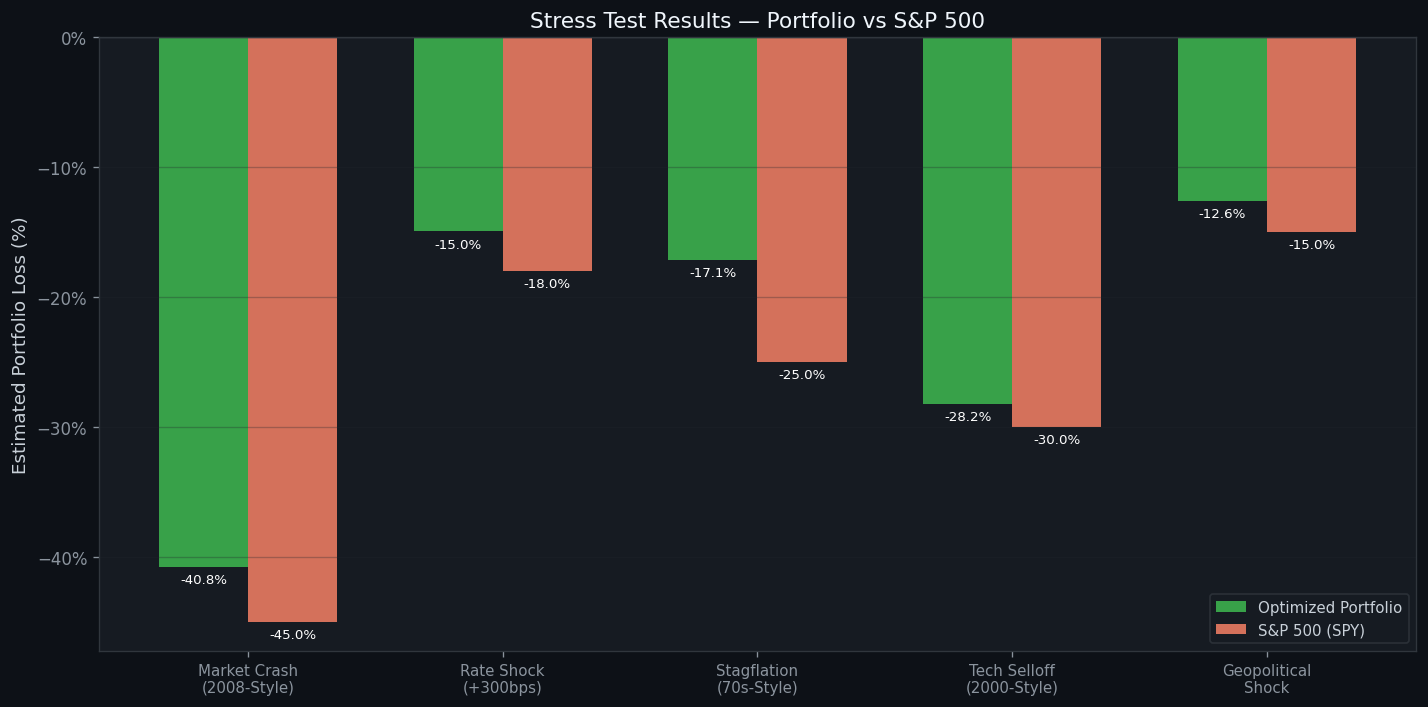

In [16]:
# ============================================================
# SECTION 15: STRESS TESTING
# ============================================================

STRESS_SCENARIOS = {
    'Market Crash\n(2008-Style)': {
        'Broad Market':  -0.45,
        'International': -0.52,
        'Dividend':      -0.38,
        'Sector':        -0.42,
        'Fixed Income':  +0.15,
        'Alternatives':  +0.05,   # gold rallies, commodities mixed
    },
    'Rate Shock\n(+300bps)': {
        'Broad Market':  -0.18,
        'International': -0.15,
        'Dividend':      -0.12,
        'Sector':        -0.15,
        'Fixed Income':  -0.22,
        'Alternatives':  -0.08,
    },
    'Stagflation\n(70s-Style)': {
        'Broad Market':  -0.25,
        'International': -0.20,
        'Dividend':      -0.10,
        'Sector':        -0.18,
        'Fixed Income':  -0.15,
        'Alternatives':  +0.20,   # commodities & gold benefit
    },
    'Tech Selloff\n(2000-Style)': {
        'Broad Market':  -0.30,
        'International': -0.22,
        'Dividend':      -0.12,
        'Sector':        -0.38,   # tech-heavy sectors hit hard
        'Fixed Income':  +0.10,
        'Alternatives':  +0.02,
    },
    'Geopolitical\nShock': {
        'Broad Market':  -0.15,
        'International': -0.25,
        'Dividend':      -0.08,
        'Sector':        -0.15,
        'Fixed Income':  +0.05,
        'Alternatives':  +0.12,   # gold safe haven
    },
}


def apply_stress(weights: pd.Series, scenario: dict, universe: dict) -> float:
    """Compute portfolio P&L under a stress scenario."""
    port_loss = 0.0
    for t, w in weights.items():
        asset_class = universe[t]['class']
        shock       = scenario.get(asset_class, -0.15)
        port_loss  += w * shock
    return port_loss


# Compare optimized portfolio vs SPY under each scenario
SPY_WEIGHTS_MOCK = pd.Series({'SPY': 1.0})

stress_results = {}
for scenario_name, shocks in STRESS_SCENARIOS.items():
    port_loss = apply_stress(final_weights, shocks, UNIVERSE)
    spy_loss  = shocks.get('Broad Market', -0.30)  # SPY = pure broad market
    stress_results[scenario_name] = {
        'Portfolio': port_loss,
        'S&P 500':   spy_loss,
        'Advantage': spy_loss - port_loss
    }

stress_df = pd.DataFrame(stress_results).T
print("=" * 65)
print("STRESS TEST RESULTS — Estimated Portfolio Loss")
print("=" * 65)
for col in ['Portfolio', 'S&P 500', 'Advantage']:
    stress_df[col] = stress_df[col].map('{:.2%}'.format)
print(stress_df.to_string())

# ── Stress Bar Chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

scenarios  = list(STRESS_SCENARIOS.keys())
port_losses = [stress_results[s]['Portfolio'] * 100 for s in scenarios]
spy_losses  = [stress_results[s]['S&P 500']  * 100 for s in scenarios]

x     = np.arange(len(scenarios))
width = 0.35

b1 = ax.bar(x - width/2, port_losses, width, label='Optimized Portfolio', color=GREEN,  alpha=0.85)
b2 = ax.bar(x + width/2, spy_losses,  width, label='S&P 500 (SPY)',       color=ORANGE, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=9)
ax.set_ylabel('Estimated Portfolio Loss (%)')
ax.set_title('Stress Test Results — Portfolio vs S&P 500', fontsize=13)
ax.legend(fontsize=9)
ax.axhline(0, color='#484f58', lw=0.8)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='top', fontsize=8, color='white')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='top', fontsize=8, color='white')

plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# SECTION 16: FINAL PORTFOLIO SUMMARY DASHBOARD
# ============================================================

print("\n" + "=" * 70)
print("  FINAL OPTIMIZED PORTFOLIO — INVESTMENT COMMITTEE SUMMARY")
print("=" * 70)
print(f"  Strategy     : Maximum Sharpe Ratio — Multi-Asset Diversified")
print(f"  Universe     : {len(TICKERS)} candidate assets → {len(FINAL_TICKERS)} final holdings")
print(f"  Data Period  : 2015-01-01 → 2024-12-31 (10 years)")
print(f"  Risk-Free Rt : {RISK_FREE:.1%}")
print("\n" + "-" * 70)
print("  PERFORMANCE METRICS")
print("-" * 70)
print(f"  Expected Annual Return  : {final_opt['return']:.2%}")
print(f"  Expected Volatility     : {final_opt['vol']:.2%}")
print(f"  Sharpe Ratio            : {final_opt['sharpe']:.3f}")
print(f"  Max Drawdown (hist.)    : {port_dd.min():.2%}")
print(f"  Calmar Ratio            : {final_opt['return'] / abs(port_dd.min()):.3f}")
print(f"  Annual Alpha vs SPY     : {final_opt['return'] - bench_stats['Ann. Return']:+.2%}")
print(f"  5-Yr Median Value ($1M) : ${p50/1e6:.2f}M")
print("\n" + "-" * 70)
print("  PORTFOLIO HOLDINGS")
print("-" * 70)
print(f"  {'Ticker':<8} {'Asset Name':<35} {'Class':<18} {'Weight'}")
print(f"  {'-'*6:<8} {'-'*33:<35} {'-'*16:<18} {'------'}")

active_wts = final_weights[final_weights > 0.001].sort_values(ascending=False)
for t, w in active_wts.items():
    cls = UNIVERSE[t]['class']
    nm  = UNIVERSE[t]['name'][:33]
    print(f"  {t:<8} {nm:<35} {cls:<18} {w:.2%}")

print("\n" + "-" * 70)
print("  ASSET CLASS ALLOCATION")
print("-" * 70)
class_alloc = {}
for t, w in active_wts.items():
    cls = UNIVERSE[t]['class']
    class_alloc[cls] = class_alloc.get(cls, 0) + w
for cls, alloc in sorted(class_alloc.items(), key=lambda x: -x[1]):
    bar_len = int(alloc * 40)
    print(f"  {cls:<18} {alloc:.2%}  {'█' * bar_len}")

print("\n" + "-" * 70)
print("  DIVERSIFICATION METRICS")
print("-" * 70)
w_arr    = active_wts.values
hhi      = np.sum(w_arr**2)
eff_n    = 1 / hhi
print(f"  # Active Holdings        : {len(active_wts)}")
print(f"  Herfindahl Index (HHI)   : {hhi:.4f} (lower = more diversified)")
print(f"  Effective N (1/HHI)      : {eff_n:.1f}")
print(f"  # Asset Classes          : {len(class_alloc)}")
print("=" * 70)



  FINAL OPTIMIZED PORTFOLIO — INVESTMENT COMMITTEE SUMMARY
  Strategy     : Maximum Sharpe Ratio — Multi-Asset Diversified
  Universe     : 22 candidate assets → 21 final holdings
  Data Period  : 2015-01-01 → 2024-12-31 (10 years)
  Risk-Free Rt : 4.5%

----------------------------------------------------------------------
  PERFORMANCE METRICS
----------------------------------------------------------------------
  Expected Annual Return  : 16.30%
  Expected Volatility     : 14.13%
  Sharpe Ratio            : 0.835
  Max Drawdown (hist.)    : -24.57%
  Calmar Ratio            : 0.663
  Annual Alpha vs SPY     : +6.69%
  5-Yr Median Value ($1M) : $2.13M

----------------------------------------------------------------------
  PORTFOLIO HOLDINGS
----------------------------------------------------------------------
  Ticker   Asset Name                          Class              Weight
  ------   ---------------------------------   ----------------   ------
  QQQ      Invesco NASDAQ-

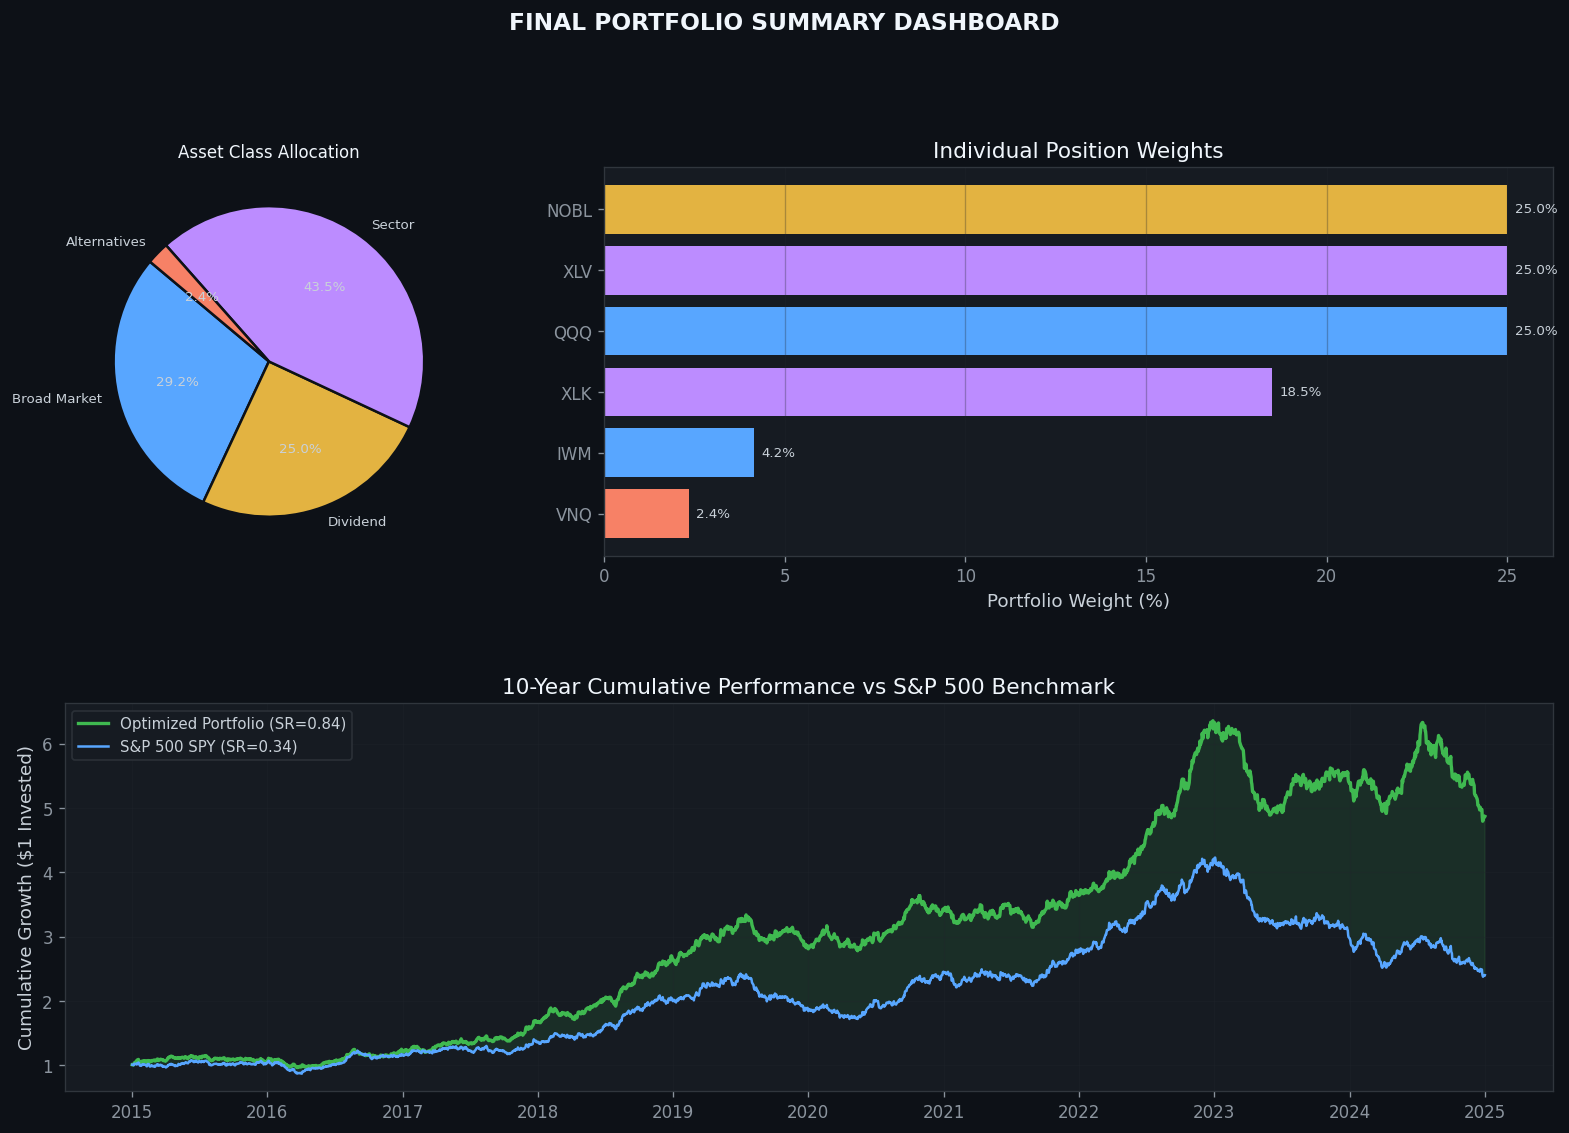

In [18]:
# ── Final Dashboard Visualization ─────────────────────────────

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# 1. Pie chart: asset class allocation
ax1 = fig.add_subplot(gs[0, 0])
class_labels = list(class_alloc.keys())
class_vals   = [class_alloc[c] for c in class_labels]
pie_colors   = [class_colors[c] for c in class_labels]
wedges, texts, autotexts = ax1.pie(
    class_vals, labels=class_labels, autopct='%1.1f%%',
    colors=pie_colors, startangle=140,
    textprops={'color': '#c9d1d9', 'fontsize': 8},
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 1.5}
)
for at in autotexts: at.set_fontsize(8)
ax1.set_title('Asset Class Allocation', fontsize=10)

# 2. Horizontal bar: position weights
ax2 = fig.add_subplot(gs[0, 1:])
sorted_wts = active_wts.sort_values()
bar_colors2 = [class_colors[UNIVERSE[t]['class']] for t in sorted_wts.index]
ax2.barh(sorted_wts.index, sorted_wts.values * 100, color=bar_colors2, edgecolor='none')
ax2.set_xlabel('Portfolio Weight (%)')
ax2.set_title('Individual Position Weights')
ax2.grid(True, alpha=0.3, axis='x')
for i, (t, w) in enumerate(sorted_wts.items()):
    ax2.text(w*100 + 0.2, i, f'{w:.1%}', va='center', fontsize=8, color='#c9d1d9')

# 3. Cumulative performance comparison
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(port_cum.index,  port_cum.values,  color=GREEN,  lw=2.0, label=f'Optimized Portfolio (SR={final_opt["sharpe"]:.2f})')
ax3.plot(bench_cum.index, bench_cum.values, color=ACCENT,  lw=1.5, label=f'S&P 500 SPY (SR={bench_stats["Sharpe Ratio"]:.2f})')
ax3.fill_between(port_cum.index, port_cum.values, bench_cum.values,
                 where=port_cum.values >= bench_cum.values,
                 alpha=0.12, color=GREEN)
ax3.fill_between(port_cum.index, port_cum.values, bench_cum.values,
                 where=port_cum.values < bench_cum.values,
                 alpha=0.12, color=ORANGE)
ax3.set_ylabel('Cumulative Growth ($1 Invested)')
ax3.set_title('10-Year Cumulative Performance vs S&P 500 Benchmark')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.suptitle('FINAL PORTFOLIO SUMMARY DASHBOARD', fontsize=14, y=1.01,
             fontweight='bold', color='#f0f6fc')
plt.show()
